# American Put Option Pricing with Discrete Dividends — Monte Carlo (Longstaff–Schwartz)

---

## 📌 Series Overview

This notebook is part of a three-part series on numerical methods for pricing **American put options with discrete dividends**:

1. **Finite Difference Method** — Solving the option pricing PDE directly, with the early exercise feature handled via an LCP.
2. **Monte Carlo (Longstaff–Schwartz)** — ✅ *(this notebook)* Using backward induction on simulated paths to estimate continuation values.
3. **Penalty Method** — Transforming the LCP into a nonlinear PDE by adding a penalty term to enforce the early exercise constraint.

---

### Motivation
Monte Carlo methods are **dimension-agnostic** and adapt well to **path-dependent** features.  
For American options, early exercise is handled via **regression-based continuation value estimation** (Longstaff–Schwartz).  
Discrete dividends are incorporated by applying **cash jumps** along simulated paths at ex-dates.

This notebook aims to:
- Implement LSMC with polynomial basis functions for continuation values.
- Incorporate discrete dividends in path simulation.
- Compare price / variance / runtime with the other methods in the series.

---

## Method Comparison

| Method                     | Strengths | Weaknesses | Best Use Cases |
|----------------------------|-----------|------------|----------------|
| **Finite Difference (LCP)** | High accuracy in 1D; stable | Complex for high dimensions | Vanilla options in 1D, sensitivity analysis |
| **Monte Carlo (LSM)** ✅    | Handles high dimensions; flexible | Slower convergence in 1D; regression bias/variance | Multi-asset, path-dependent options |
| **Penalty Method**         | No explicit free boundary; customizable | Sensitive to λ and grid size | Exotic payoffs, finite element frameworks |

---

## Discrete Dividends in Simulation
For each ex-date \(t_d\) with cash dividend \(D\), apply:
\[
S_{t_d^+} = \max(S_{t_d^-} - D,\,0),
\]
with paths continuing from \(S_{t_d^+}\).

---

## Parameters

| Symbol      | Description                         | Example |
|-------------|-------------------------------------|---------|
| \( K \)     | Strike price                        | 50      |
| \( T \)     | Time to maturity (years)            | 1.0     |
| \( r \)     | Risk-free rate                      | 5%      |
| \( \sigma \)| Volatility                           | 20%     |
| \( M \)     | Time steps per path                  | 100–250 |
| \( \mathcal{P} \) | Number of simulated paths     | 50k–200k |
| Basis       | Regressors for LSM (e.g., \([1,S,S^2]\)) | \([1,S,S^2]\) |
| Seed        | RNG seed for reproducibility         | 42      |

---

## Implementation Steps
1. Simulate GBM paths with discrete dividend jumps at ex-dates.
2. Work backward over exercise dates:
   - Regress discounted cashflows on basis functions of \(S\) to estimate continuation value.
   - Exercise when payoff \(\ge\) continuation.
3. Average discounted cashflows for the price estimate.
4. Analyze sensitivity to path count, basis, and exercise dates; compare to PDE methods.


In [2]:
# --- Core Python Packages ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration for Plotting ---
plt.style.use("ggplot")
%matplotlib inline

# --- Project Modules ---
import sys
import os
sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../volatility"))

from pricing.monte_carlo import longstaff_schwartz, value_all_S, plot_lsmc_paths
from vol.svi_fit import fit_svi_slice, svi_w
from vol.svi import get_scaled_vol
from curves.hagan_west import bootstrap_discounts_hg, average_forwards, hagan_west_forward, build_discount_and_zero_from_forward_hg

ModuleNotFoundError: No module named 'pricing'

In [6]:
#pip install longstaff_schwartz
import longstaff_schwartz
longstaff_schwartz

<module 'longstaff_schwartz' from '/usr/local/lib/python3.12/dist-packages/longstaff_schwartz/__init__.py'>

In [11]:
dir(longstaff_schwartz)

['__author__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__email__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__']

In [17]:
import longstaff_schwartz.stochastic_process as foo

In [19]:
dir(foo)

['BrownianMotion',
 'GeometricBrownianMotion',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'lognorm',
 'norm',
 'np',
 'rv_frozen']

In [12]:
from longstaff_schwartz.algorithm import longstaff_schwartz
from longstaff_schwartz.stochastic_process import GeometricBrownianMotion

In [16]:
print(inspect.getsource(longstaff_schwartz))

def longstaff_schwartz(X, t, df, fit, exercise_payoff, itm_select=None):
    for cashflow, *_ in longstaff_schwartz_iter(
        X, t, df, fit, exercise_payoff, itm_select
    ):
        pass
    return cashflow.mean(axis=0) * df(t[0], t[1])



### Simulation
We first perform simulations to see the difference in prices and boundaries in the cases with and without dividends.

In [ ]:
# --- Simulation Parameters ---
T = 1.0
S = 50
S_max = 100
K = 50
r = 0.05
sigma = 0.25
N= 500 # Timesteps
M= 100000 # Number of paths
dividends = [(0.5, 2.0)]

In [ ]:
%%time
# === Compute American option value at S = 50
V0_nodiv, _, _ = longstaff_schwartz(K, T, r, sigma, S, N, M, dividends=[])           # No dividends

CPU times: user 1min, sys: 1.7 s, total: 1min 2s
Wall time: 7.1 s


In [ ]:
V0_div,   _, _ = longstaff_schwartz(K, T, r, sigma, S, N, M, dividends=dividends)    # With dividends

In [ ]:
# === Find index closest to S = 50 ===
diff_val = V0_nodiv - V0_div

# === Print nicely
print(f"Stock Price S = {S:.2f}")
print(f"No Dividend   = {V0_nodiv:.4f}")
print(f"With Dividend = {V0_div:.4f}")
print(f"Difference    = {diff_val:.4f}")


Stock Price S = 50.00
No Dividend   = 4.0462
With Dividend = 5.0374
Difference    = -0.9912


In [ ]:
# === Compute option values, early exercise boundaries, and diffs across S0
dS = 1000
grid, values_withdiv, _, diffs_withdiv = value_all_S(K, T, r, sigma, N, dS, S_max, dividends=dividends)
_, values_nodiv, _, diffs_nodiv = value_all_S(K, T, r, sigma, N, dS, S_max, dividends=[])

In [ ]:
# Intrinsic value at t=0 for each S0
intrinsic = np.maximum(K - grid, 0)

# Compute average continuation - intrinsic difference across paths
avg_diff_withdiv = diffs_withdiv
avg_diff_nodiv = diffs_nodiv

# Define threshold for identifying early exercise
epsilon = 0.5

# Identify S0 values where immediate exercise is optimal
exercise_now_mask_withdiv = avg_diff_withdiv > epsilon
exercise_now_S_withdiv = grid[exercise_now_mask_withdiv]

exercise_now_mask_nodiv = avg_diff_nodiv > epsilon
exercise_now_S_nodiv = grid[exercise_now_mask_nodiv]

# Compute exercise boundary S*(0)
if len(exercise_now_S_withdiv) > 0:
    S_star_0_withdiv = np.min(exercise_now_S_withdiv)
    print(f"Exercise boundary at time 0 (with dividend): S*(0) ≈ {S_star_0_withdiv:.4f}")
else:
    S_star_0_withdiv = None
    print("No immediate exercise is optimal at time 0 (with dividend).")

if len(exercise_now_S_nodiv) > 0:
    S_star_0_nodiv = np.min(exercise_now_S_nodiv)
    print(f"Exercise boundary at time 0 (no dividend): S*(0) ≈ {S_star_0_nodiv:.4f}")
else:
    S_star_0_nodiv = None
    print("No immediate exercise is optimal at time 0 (no dividend).")


Exercise boundary at time 0 (with dividend): S*(0) ≈ 1.8930
Exercise boundary at time 0 (no dividend): S*(0) ≈ 40.3995


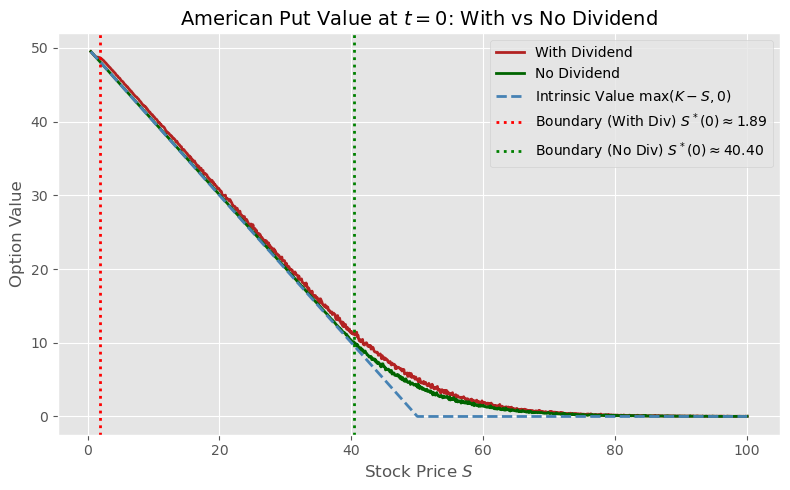

In [ ]:
plt.figure(figsize=(8, 5))

# Plot values
plt.plot(grid, values_withdiv, label=r"With Dividend", color='firebrick', lw=2)
plt.plot(grid, values_nodiv, label=r"No Dividend", color='darkgreen', lw=2)

# Plot intrinsic value
plt.plot(grid, intrinsic, label=r"Intrinsic Value $\max(K - S, 0)$", linestyle='--', color='steelblue', lw=2)

# Plot early exercise boundary (with dividend)
if S_star_0_withdiv is not None:
    plt.axvline(S_star_0_withdiv, linestyle=':', color='red', lw=2,
                label=fr"Boundary (With Div) $S^*(0) \approx {S_star_0_withdiv:.2f}$")

# Plot early exercise boundary (no dividend)
if S_star_0_nodiv is not None:
    plt.axvline(S_star_0_nodiv, linestyle=':', color='green', lw=2,
                label=fr"Boundary (No Div) $S^*(0) \approx {S_star_0_nodiv:.2f}$")

# Final plot settings
plt.title(r"American Put Value at $t = 0$: With vs No Dividend", fontsize=14)
plt.xlabel("Stock Price $S$", fontsize=12)
plt.ylabel("Option Value", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


LSMC results are too jiggly to be reliale in finding the exercise prices. Despite that, the boundaries are of similar magnitude compared with those from the finite difference method. Perhaps with higer number of paths (M) and ds we could alleviate this problem, but Python is too slow, I will implement LSMC with C++ later.

This result is similar to the finite difference (FD) method, the exercise price is similar but a bit lower (1.2 < 1.6).

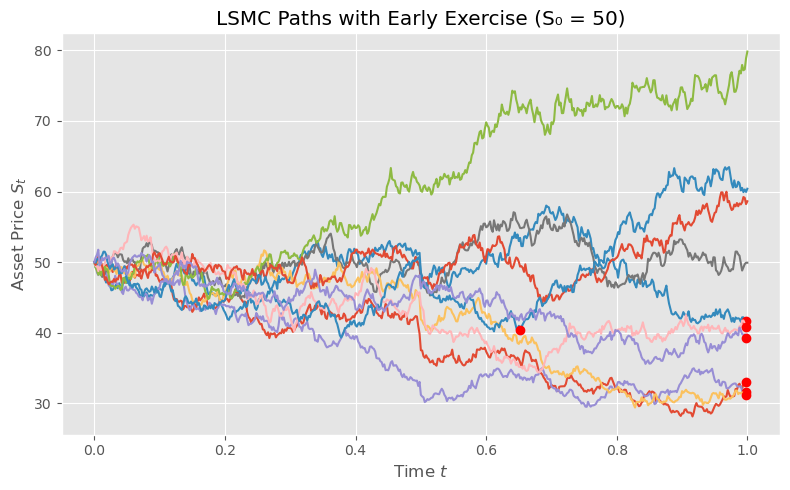

In [ ]:
# Plot LSMC paths and early exercises -- Only 10 paths are shown here.
plot_lsmc_paths(K=K, T=T, r=r, sigma=sigma, S_0=S, N=N, M=M, dividends = dividends)

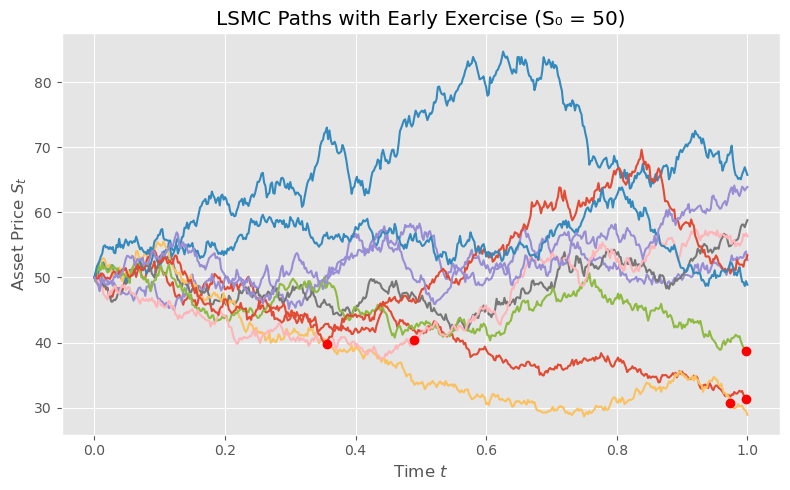

In [ ]:
# Plot LSMC paths and early exercises -- Only 10 paths are shown here.
plot_lsmc_paths(K=K, T=T, r=r, sigma=sigma, S_0=S, N=N, M=M, dividends = [])

To see how a later dividend impacts the optimal stopping decision, together with the value of the option, ceteris paribus.

In [ ]:
dividends_later = [(0.95, 2.0)]
V0_laterdiv,_,  _ = longstaff_schwartz(K, T, r, sigma, S, N, M, dividends=dividends_later)

In [ ]:
# === Find index closest to S = 50 ===
diff_val = V0_laterdiv - V0_div

# === Print nicely
print(f"Stock Price S = {S:.2f}")
print(f"Late Dividend   = {V0_laterdiv:.4f}")
print(f"Early Dividend = {V0_div:.4f}")
print(f"Difference    = {diff_val:.4f}")

Stock Price S = 50.00
Late Dividend   = 4.7546
Early Dividend = 5.0374
Difference    = -0.2828


In [ ]:
# === Compute option values and intrinsic for range of S0
grid, values_later, _ , diffs_later = value_all_S(K, T, r, sigma, N, dS, S_max, dividends=dividends_later)
values_early, diffs_early = values_withdiv, diffs_withdiv

In [ ]:
# === Compute intrinsic value only once
intrinsic = np.maximum(K - grid, 0)
epsilon = 0.5

# === Use already computed values_early and values_later
diffs_early = values_early - intrinsic
diffs_later = values_later - intrinsic

exercise_now_early = grid[diffs_early > epsilon]
exercise_now_later = grid[diffs_later > epsilon]

S_star_0_early = np.min(exercise_now_early) if len(exercise_now_early) > 0 else None
S_star_0_later = np.min(exercise_now_later) if len(exercise_now_later) > 0 else None

# === Print only once
print("=== Early Exercise Boundary at Time 0 ===")
print(f"→ With Early Dividend: S*(0) ≈ {S_star_0_early:.4f}" if S_star_0_early else "→ With Early Dividend: No immediate exercise is optimal")
print(f"→ With Late Dividend:  S*(0) ≈ {S_star_0_later:.4f}"  if S_star_0_later  else "→ With Late Dividend: No immediate exercise is optimal")

=== Early Exercise Boundary at Time 0 ===
→ With Early Dividend: S*(0) ≈ 1.8930
→ With Late Dividend:  S*(0) ≈ 34.7280


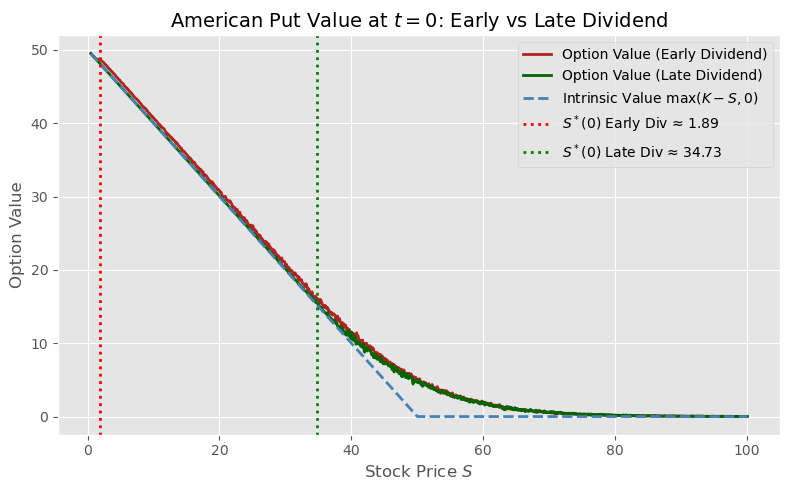

In [ ]:
# === Plot comparison between early and late dividend impact ===
plt.figure(figsize=(8, 5))

# Plot American put values at t = 0
plt.plot(grid, values_early, label=r"Option Value (Early Dividend)", color='firebrick', lw=2)
plt.plot(grid, values_later, label=r"Option Value (Late Dividend)", color='darkgreen', lw=2)

# Plot intrinsic value
plt.plot(grid, intrinsic, label=r"Intrinsic Value $\max(K - S, 0)$", linestyle='--', color='steelblue', lw=2)

# Vertical lines for early and late dividend boundaries
if S_star_0_early is not None:
    plt.axvline(S_star_0_early, linestyle=':', color='red', lw=2,
                label=fr"$S^*(0)$ Early Div ≈ {S_star_0_early:.2f}")

if S_star_0_later is not None:
    plt.axvline(S_star_0_later, linestyle=':', color='green', lw=2,
                label=fr"$S^*(0)$ Late Div ≈ {S_star_0_later:.2f}")

# Final plot settings
plt.title(r"American Put Value at $t = 0$: Early vs Late Dividend", fontsize=14)
plt.xlabel("Stock Price $S$", fontsize=12)
plt.ylabel("Option Value", fontsize=12)
plt.grid(True)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


We can see that the later dividend decreases the value at time 0. It also encourages for earlier exercise. Intuitively later dividends reduce likelihood that one can reap the benefits of the decrease in the underlying price.

Next, let's investigate the sigmas.

In [ ]:
sigma_high = 0.45
V0_sigmahigh, _,  _ = longstaff_schwartz(K, T, r, sigma_high, S, N, M, dividends=[])

In [ ]:
# === Find index closest to S = 50 ===
diff_val = V0_sigmahigh - V0_nodiv

# === Print nicely
print(f"Stock Price S = {S:.2f}")
print(f"With 45 percent volatility   = {V0_sigmahigh:.4f}")
print(f"With 25 percent volatility = {V0_nodiv:.4f}")
print(f"Difference    = {diff_val:.4f}")

Stock Price S = 50.00
With 45 percent volatility   = 7.8980
With 25 percent volatility = 4.0462
Difference    = 3.8517


In [ ]:
# === Compute option values and intrinsic for range of S0
grid, values_highsigma, _ , diffs_highsigma = value_all_S(K, T, r, sigma_high, N, dS, S_max, dividends=[])
values_lowsigma, diffs_lowsigma = values_nodiv, diffs_nodiv

In [ ]:
# === Compute intrinsic value only once
intrinsic = np.maximum(K - grid, 0)
epsilon = 0.5

# === Use already computed values_early and values_later
diffs_lowsigma = values_lowsigma - intrinsic
diffs_highsigma = values_highsigma - intrinsic

exercise_now_lowsigma = grid[diffs_lowsigma > epsilon]
exercise_now_highsigma = grid[diffs_highsigma > epsilon]

S_star_0_lowsigma = np.min(exercise_now_lowsigma) if len(exercise_now_lowsigma) > 0 else None
S_star_0_highsigma = np.min(exercise_now_highsigma) if len(exercise_now_highsigma) > 0 else None

# === Print only once
print("=== Early Exercise Boundary at Time 0 ===")
print(f"→ With 25 percent volatility: S*(0) ≈ {S_star_0_lowsigma:.4f}" if S_star_0_lowsigma else "→ With Early Dividend: No immediate exercise is optimal")
print(f"→ With 45 percent volatility:  S*(0) ≈ {S_star_0_highsigma:.4f}"  if S_star_0_highsigma  else "→ With Late Dividend: No immediate exercise is optimal")

=== Early Exercise Boundary at Time 0 ===
→ With 25 percent volatility: S*(0) ≈ 40.3995
→ With 45 percent volatility:  S*(0) ≈ 28.5590


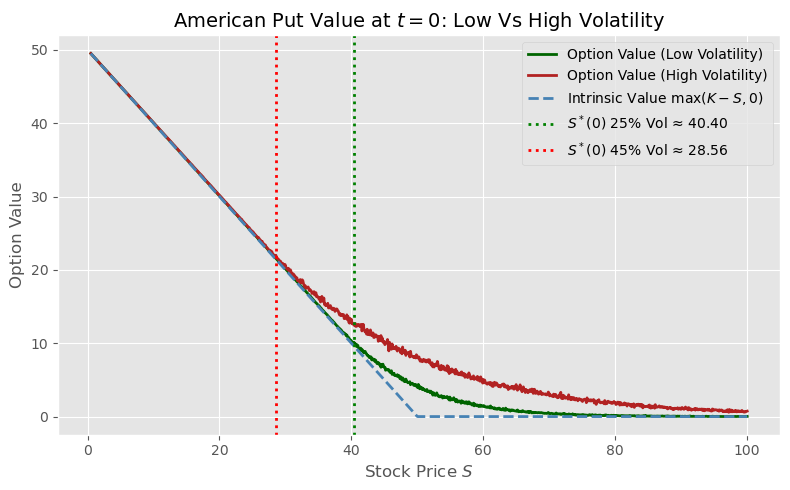

In [ ]:
# === Plot comparison between early and late dividend impact ===
plt.figure(figsize=(8, 5))

# Plot American put values at t = 0
plt.plot(grid, values_lowsigma, label=r"Option Value (Low Volatility)", color='darkgreen', lw=2)
plt.plot(grid, values_highsigma, label=r"Option Value (High Volatility)", color='firebrick', lw=2)

# Plot intrinsic value
plt.plot(grid, intrinsic, label=r"Intrinsic Value $\max(K - S, 0)$", linestyle='--', color='steelblue', lw=2)

# Vertical lines for early and late dividend boundaries
if S_star_0_early is not None:
    plt.axvline(S_star_0_lowsigma, linestyle=':', color='green', lw=2,
                label=fr"$S^*(0)$ 25% Vol ≈ {S_star_0_lowsigma:.2f}")

if S_star_0_later is not None:
    plt.axvline(S_star_0_highsigma, linestyle=':', color='red', lw=2,
                label=fr"$S^*(0)$ 45% Vol ≈ {S_star_0_highsigma:.2f}")

# Final plot settings
plt.title(r"American Put Value at $t = 0$: Low Vs High Volatility", fontsize=14)
plt.xlabel("Stock Price $S$", fontsize=12)
plt.ylabel("Option Value", fontsize=12)
plt.grid(True)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

As expected, first higher volatilities give rise to higher option prices. Second, higher volatilites push down the exercise prices at the beginning. Intuition is that there is higher chance of the price to be lower afterwards, thus more chance of the American put options to become more profitable later.

### Convergence Test
This section aims to test whether our LSMC simulation converges as M (paths) become bigger. This can be checked by the standard errors of the prices. If convergent, the LSMC would yield outputs with smaller standard errors as the number of paths increase.

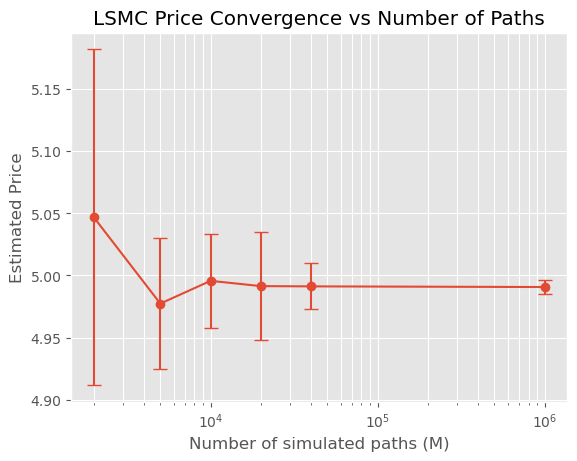

CPU times: user 7min 13s, sys: 1min 40s, total: 8min 53s
Wall time: 1min 5s


In [ ]:
%%time
def lsmc_price_once(K, T, r, sigma, S0, N, M, dividends):
    V0, _, _ = longstaff_schwartz(K, T, r, sigma, S0, N, M, dividends=dividends)
    return V0

# Experiment parameters
K = 50
T = 1.0
r = 0.05
sigma = 0.25
S0 = 50
dividends = [(0.5, 2.0)]

M_list = [2000, 5000, 10000, 20000, 40000, 1000000]
N_steps = 100  # fixed large number of exercise dates

prices = []
stderr = []

# Multiple runs to estimate standard error
n_runs = 5
for M in M_list:
    vals = [lsmc_price_once(K, T, r, sigma, S0, N_steps, M, dividends) for _ in range(n_runs)]
    mean_val = np.mean(vals)
    se = np.std(vals, ddof=1) / np.sqrt(n_runs)
    prices.append(mean_val)
    stderr.append(se)

# Plot convergence in paths
import matplotlib.pyplot as plt
plt.errorbar(M_list, prices, yerr=1.96*np.array(stderr), fmt='o-', capsize=5)
plt.xscale('log')
plt.xlabel("Number of simulated paths (M)")
plt.ylabel("Estimated Price")
plt.title("LSMC Price Convergence vs Number of Paths")
plt.grid(True, which='both')
plt.show()

### Pricing using the Longstaff-Schwartz Monte Carlo Simulation and Corresponding Market Prices

In [ ]:
# --- Load SVI Parameters (Calibrated on SPX Surface) ---
import pickle
with open("../data/svi_params_2025-07-22.pkl", "rb") as f:
    svi_param_dict = pickle.load(f)

In [ ]:
# --- Set Market Parameters ---
spy_spot = 628.86   # example SPY spot
spx_spot = 6309.62  # example SPX spot
scaling_factor = spx_spot / spy_spot
valuation_date = pd.to_datetime("2025-07-22")

In [ ]:
# --- Yield Curve Calibration ---
df = pd.read_csv("../data/daily_treasury_par_rates.csv",parse_dates=['Date'])
row = df[df['Date']==pd.to_datetime(valuation_date)]
cols = [col for col in df.columns if col != 'Date']
vals = row.iloc[0, 1:].values  # excludes 'Date'
par_rates = dict(zip(cols, vals))
par_rates = {round(float(k), 6): v for k, v in par_rates.items()}

# Bootstrap + Forward + Interpolate + Zero
discounts_mc = bootstrap_discounts_hg(par_rates)
T_hw, P_hw, fbar_hw = average_forwards(discounts_mc)
f_fn, F_int = hagan_west_forward(T_hw, fbar_hw)
P_fn, z_fn  = build_discount_and_zero_from_forward_hg(f_fn, F_int)

In [ ]:
# --- Load SPY Option Market Data ---
df = pd.read_csv("../data/spy_american_put_mid_price.csv")
df = df[df["MidPrice"] > 0].copy()
df["Expiry"] = pd.to_datetime(df["Expiry"])
valuation_date = pd.to_datetime("2025-07-22")
df["T"] = (df["Expiry"] - valuation_date).dt.days / 365.0

In [ ]:
# --- Parameters ---
S_max_factor = 2.0
M = 100000          # simulated paths
N = 100          # time steps


In [ ]:
# --- Future Ex-Dividend Dates ---
ex_div = {'2025-09-19':1.7,'2025-12-19':1.7,'2026-03-20':1.7,'2026-06-18':1.7}
ex_div = {pd.to_datetime(p):q for p,q in ex_div.items()}

In [ ]:
df['Dividend'] = pd.Series([None] * len(df), dtype='object')
for idx, row in df.iterrows():
    dividend_schedule = []
    expiry = row['Expiry']

    for date, div in ex_div.items():
        if (expiry-date).days > 0:
            diff = (expiry-date).days / 365
            dividend_schedule.append((diff, div))

    df.at[idx, 'Dividend'] = dividend_schedule

In [ ]:
df.tail()

,Expiry,Strike,Bid,Ask,MidPrice,T,Dividend
43,2025-10-31,630,16.90,16.95,16.925,0.276712,"[(0.11506849315068493, 1.7)]"
44,2025-10-31,635,18.65,18.71,18.680,0.276712,"[(0.11506849315068493, 1.7)]"
45,2025-10-31,640,20.65,20.71,20.680,0.276712,"[(0.11506849315068493, 1.7)]"
46,2025-10-31,645,22.94,23.00,22.970,0.276712,"[(0.11506849315068493, 1.7)]"
47,2025-10-31,650,25.49,25.70,25.595,0.276712,"[(0.11506849315068493, 1.7)]"


Indeed, as expected we observe smaller standard errors as M (paths) increases.

In [ ]:
%%time
# --- Price using Finite Difference and Compare ---
results = []
for _, row in df.iterrows():
    K, T, market_price, dividends, expiry = row["Strike"], row["T"], row["MidPrice"], row["Dividend"], row["Expiry"]
    r = z_fn([T])
    try:
        sigma = get_scaled_vol(
            K_spy=K,
            T=T,
            S0_spy=spy_spot,
            spx_spot=spx_spot,
            svi_param_dict=svi_param_dict,
            r=r
        )
        model_price, _, _ = longstaff_schwartz(K, T, r, sigma, spy_spot, N, M, dividends=dividends)
        results.append((K, expiry, T, sigma, market_price, model_price))
    except Exception as e:
        print(f"Skipped K={K}, T={T:.4f}: {e}")
        continue

CPU times: user 8min 52s, sys: 1min 6s, total: 9min 58s
Wall time: 59.5 s


In [ ]:
# --- Store and Evaluate Results ---
results_df = pd.DataFrame(results, columns=["Strike", "Expiry", "T", "ImpliedVol", "MarketPrice", "ModelPrice"])
results_df["AbsError"] = np.abs(results_df["ModelPrice"] - results_df["MarketPrice"])
#results_df.sort_values("AbsError")
results_df.head()

,Strike,Expiry,T,ImpliedVol,MarketPrice,ModelPrice,AbsError
0,628,2025-08-15,0.065753,[0.10152347773312223],6.650,5.478632,1.171368
1,629,2025-08-15,0.065753,[0.1007491140200679],6.985,5.891198,1.093802
2,630,2025-08-15,0.065753,[0.09997076536731646],7.335,6.333960,1.001040
3,631,2025-08-15,0.065753,[0.09918833467844254],7.710,6.785249,0.924751
4,632,2025-08-15,0.065753,[0.09840172129603685],8.105,7.322807,0.782193


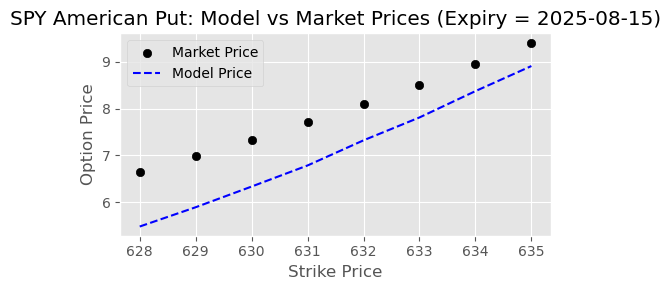

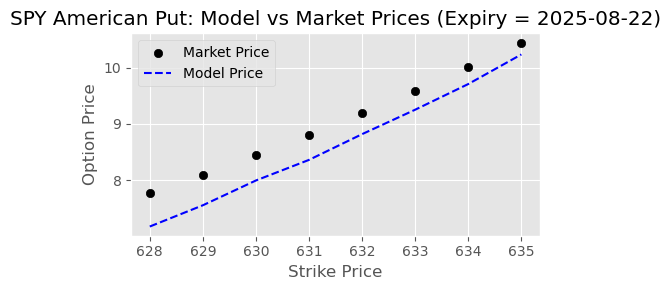

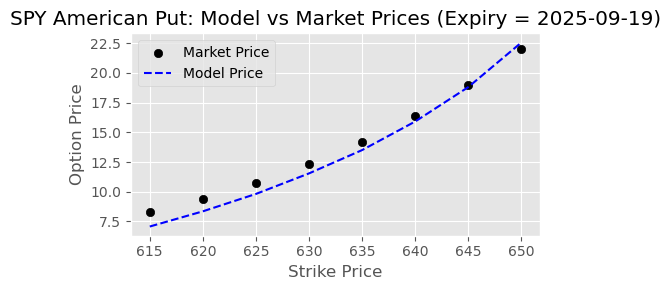

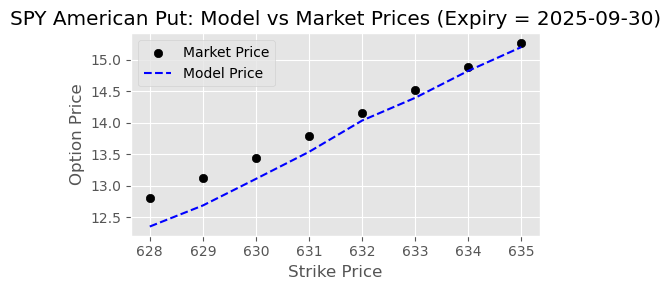

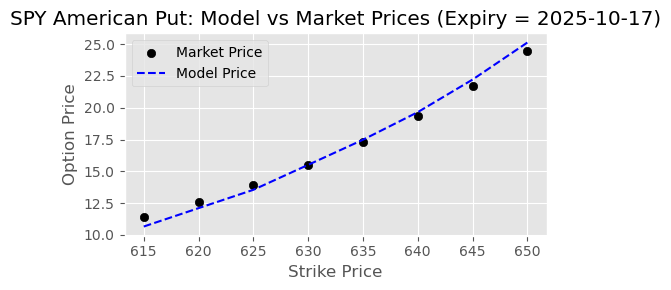

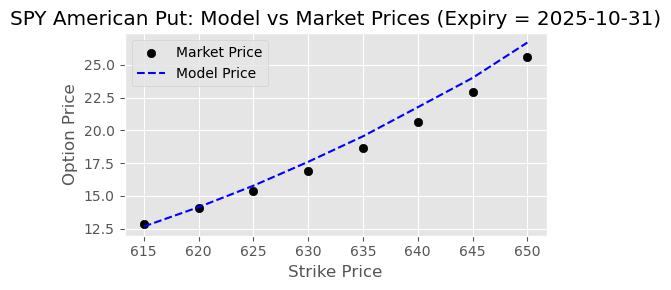

In [ ]:
# Ensure T is grouped correctly
grouped = results_df.groupby("Expiry")

for expiry, group in grouped:
    plt.figure(figsize=(5, 3))
    plt.scatter(group["Strike"], group["MarketPrice"], label="Market Price", color="black", marker="o")
    plt.plot(group["Strike"], group["ModelPrice"], label="Model Price", color="blue", linestyle="--")

    plt.xlabel("Strike Price")
    plt.ylabel("Option Price")
    plt.title(f"SPY American Put: Model vs Market Prices (Expiry = {expiry.strftime('%Y-%m-%d')})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
market = np.array([row[4] for row in results])  # market prices
model = np.array([row[5] for row in results])   # model prices

mae = np.mean(np.abs(model - market))
rmse = np.sqrt(np.mean((model - market)**2))
mape = np.mean(np.abs((model - market) / market)) * 100
r2 = 1 - np.sum((model - market)**2) / np.sum((market - np.mean(market))**2)

print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAPE = {mape:.2f}%")
print(f"R^2  = {r2:.4f}")

MAE  = 0.5500
RMSE = 0.6423
MAPE = 4.99%
R^2  = 0.9830


### Discussion
Albeit computationally slower compared with the Finite Difference (FD) method, the LSMC method performs very well: the method is convergent, yield theoretically valid and empirically realistic results. A major advantage of the LSMC method compared with the FD method is that LSMC is flexible. We can customize the underlying in any way we want and we will still be able to get the price of the asset. The trade off is only in term of the result being less clean due to its randomness.

---
### 📎 Next in the Series
- **Finite Difference Method** — High accuracy in 1D; solves LCP directly.
- **Monte Carlo (Longstaff–Schwartz)** — Flexible, handles high dimensions.
- **Penalty Method** — No explicit free boundary; highly customizable.
